In [61]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.preprocessing import Imputer
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [3]:
col = ['sep_len','sep_wid','pet_len','pet_wid','spec']
iris = pd.read_csv("iris.data",names=col)
iris.sample(n=10)

,sep_len,sep_wid,pet_len,pet_wid,spec
50,7.0,3.2,4.7,1.4,Iris-versicolor
148,6.2,3.4,5.4,2.3,Iris-virginica
40,5.0,3.5,1.3,0.3,Iris-setosa
53,5.5,2.3,4.0,1.3,Iris-versicolor
106,4.9,2.5,4.5,1.7,Iris-virginica
97,6.2,2.9,4.3,1.3,Iris-versicolor
111,6.4,2.7,5.3,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
123,6.3,2.7,4.9,1.8,Iris-virginica
42,4.4,3.2,1.3,0.2,Iris-setosa


In [4]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sep_len    150 non-null float64
sep_wid    150 non-null float64
pet_len    150 non-null float64
pet_wid    150 non-null float64
spec       150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [5]:
#There are no missing values. But in case we want to replace all zeros with median values then we can do it in this way.
def replacewithmedian(X,col):
    X[col] = X[col].replace(0,X[col].median())

replacewithmedian(iris,"sep_len")
replacewithmedian(iris,"sep_wid")
replacewithmedian(iris,"pet_len")
replacewithmedian(iris,"pet_wid")
iris.head()

,sep_len,sep_wid,pet_len,pet_wid,spec
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [6]:
iris['spec']=iris['spec'].astype('category').cat.codes
iris.sample(10)

,sep_len,sep_wid,pet_len,pet_wid,spec
99,5.7,2.8,4.1,1.3,1
75,6.6,3.0,4.4,1.4,1
76,6.8,2.8,4.8,1.4,1
123,6.3,2.7,4.9,1.8,2
144,6.7,3.3,5.7,2.5,2
17,5.1,3.5,1.4,0.3,0
106,4.9,2.5,4.5,1.7,2
113,5.7,2.5,5.0,2.0,2
110,6.5,3.2,5.1,2.0,2
100,6.3,3.3,6.0,2.5,2


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [52]:
iris.corr()

,sep_len,sep_wid,pet_len,pet_wid,spec
sep_len,1.000000,-0.109369,0.871754,0.817954,0.782561
sep_wid,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
pet_len,0.871754,-0.420516,1.000000,0.962757,0.949043
pet_wid,0.817954,-0.356544,0.962757,1.000000,0.956464
spec,0.782561,-0.419446,0.949043,0.956464,1.000000


## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [53]:
iris.var()

sep_len    0.685694
sep_wid    0.188004
pet_len    3.113179
pet_wid    0.582414
spec       0.671141
dtype: float64

## Question 6

*Plot the scatter matrix for all the variables.*

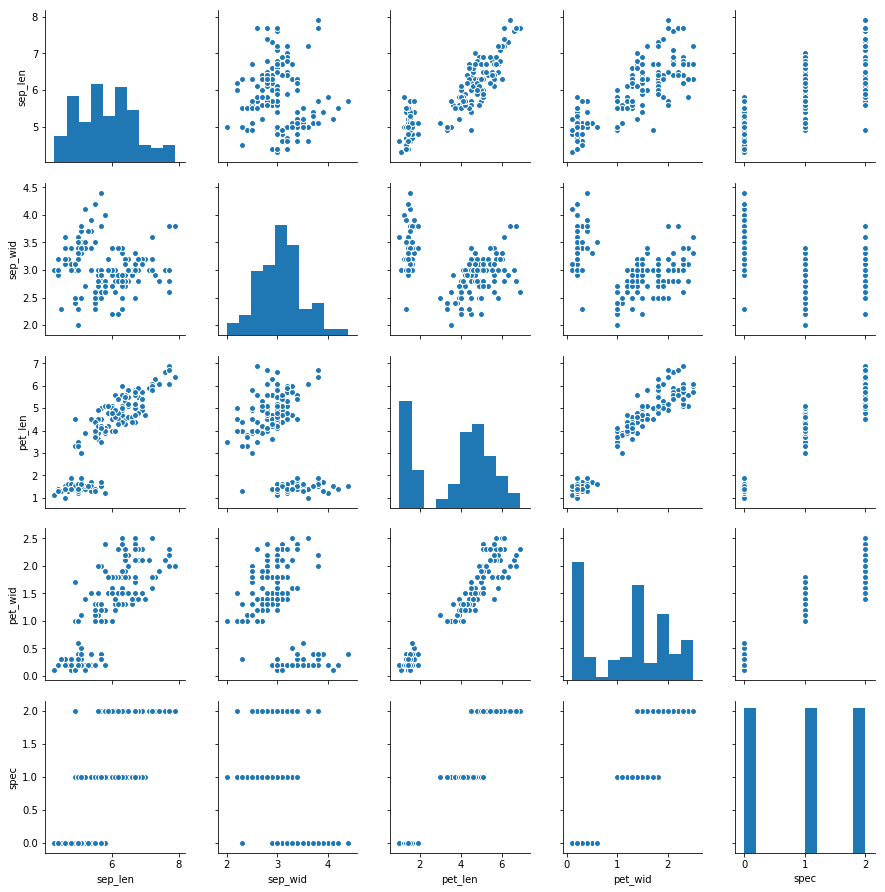

In [116]:
sns.pairplot(iris)

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [79]:
X = iris.drop(labels='spec',axis=1)
X = X.apply(zscore)
y = iris[['spec']]
test_size = 0.20 # taking 80:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [82]:
def get_accuracy_score(k):
    acc_list = []
    for x in k:
        NNH = KNeighborsClassifier(n_neighbors= x)
        NNH.fit(X_train, y_train)
        predicted_labels = NNH.predict(X_test)
        acc_list.append([x,accuracy_score(y_test,predicted_labels),(1 - accuracy_score(y_test,predicted_labels))])   
    return acc_list

In [87]:
k = [3,5,9]
pd.DataFrame(get_accuracy_score(k),columns=['K_value','Accuracy Score','MSE'])

,K_value,Accuracy Score,MSE
0,3,0.866667,0.133333
1,5,0.900000,0.100000
2,9,0.900000,0.100000


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [106]:
k = np.arange(1,20,2)
acc_Df = pd.DataFrame(get_accuracy_score(k),columns=['K_value','Accuracy Score','MSE'])
acc_Df[acc_Df.MSE == acc_Df.MSE.min()]

#MSE is less for K = 7

,K_value,Accuracy Score,MSE
3,7,0.933333,0.066667


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

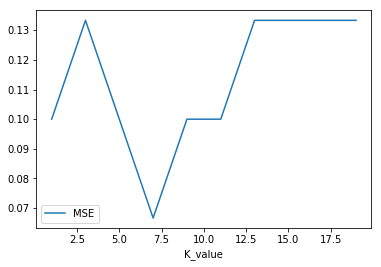

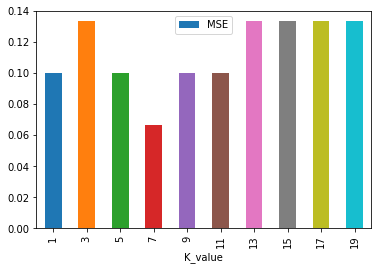

In [109]:
acc_Df.plot(kind='line',x='K_value',y='MSE')
acc_Df.plot(kind='bar',x='K_value',y='MSE')

# Naive Bayes with Iris Data

In [154]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [308]:
X = iris.drop(labels='spec',axis=1)
y = iris[['spec']]


In [113]:
#Check the dataset
print(y)
print(X)

     spec
0       0
1       0
2       0
3       0
4       0
5       0
6       0
7       0
8       0
9       0
10      0
11      0
12      0
13      0
14      0
15      0
16      0
17      0
18      0
19      0
20      0
21      0
22      0
23      0
24      0
25      0
26      0
27      0
28      0
29      0
..    ...
120     2
121     2
122     2
123     2
124     2
125     2
126     2
127     2
128     2
129     2
130     2
131     2
132     2
133     2
134     2
135     2
136     2
137     2
138     2
139     2
140     2
141     2
142     2
143     2
144     2
145     2
146     2
147     2
148     2
149     2

[150 rows x 1 columns]
     sep_len  sep_wid  pet_len  pet_wid
0        5.1      3.5      1.4      0.2
1        4.9      3.0      1.4      0.2
2        4.7      3.2      1.3      0.2
3        4.6      3.1      1.5      0.2
4        5.0      3.6      1.4      0.2
5        5.4      3.9      1.7      0.4
6        4.6      3.4      1.4      0.3
7        5.0      3.4      1.5      

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

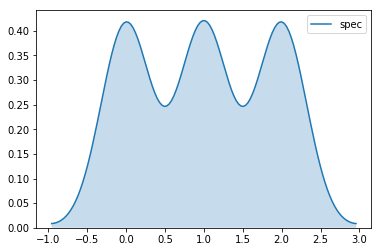

In [131]:
sns.kdeplot(iris['spec'],shade=True)

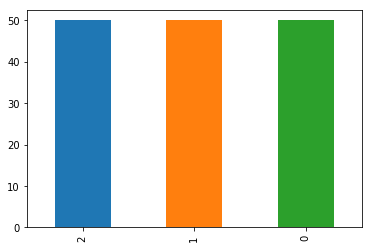

In [119]:
iris['spec'].value_counts().plot.bar()

In [0]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [121]:
iris.corr()

,sep_len,sep_wid,pet_len,pet_wid,spec
sep_len,1.000000,-0.109369,0.871754,0.817954,0.782561
sep_wid,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
pet_len,0.871754,-0.420516,1.000000,0.962757,0.949043
pet_wid,0.817954,-0.356544,0.962757,1.000000,0.956464
spec,0.782561,-0.419446,0.949043,0.956464,1.000000


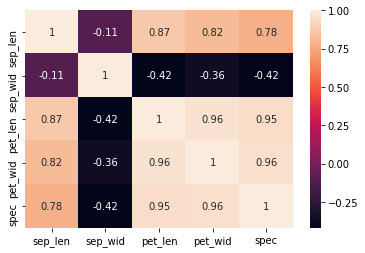

In [123]:
sns.heatmap(iris.corr(),annot=True)

In [309]:
X_vif = X.copy()
#this function will get the VIF and drop the column which have VIF greater than 10
def get_vif(df):
    vif_df = pd.DataFrame()
    vif_df["colname"] = df.columns
    vif_df["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif_df.sort_values('VIF',inplace=True,ascending=False)
    print(vif_df)
    if (vif_df.iloc[0,1] > 10):
        df = df.drop([vif_df.iloc[0,0]],axis=1)
    return(df)
X_vif = get_vif(X_vif)
X_vif.head()
#dropped sepal length due to high VIF

   colname         VIF
0  sep_len  264.745711
2  pet_len  173.968965
1  sep_wid   97.111606
3  pet_wid   55.488689


,sep_wid,pet_len,pet_wid
0,3.5,1.4,0.2
1,3.0,1.4,0.2
2,3.2,1.3,0.2
3,3.1,1.5,0.2
4,3.6,1.4,0.2


In [310]:
X_vif = get_vif(X_vif)
X_vif.head(3)
#dropped petal length due to high VIF

   colname        VIF
1  pet_len  61.750178
2  pet_wid  42.917554
0  sep_wid   5.896727


,sep_wid,pet_wid
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2


In [311]:
X_vif = get_vif(X_vif)
X_vif.head(3)
#No columns are dropped since VIF is less than 10

   colname       VIF
0  sep_wid  2.897752
1  pet_wid  2.897752


,sep_wid,pet_wid
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2


### Split data in Training and test set in 80:20.

In [125]:
#this is not required here. it should be done after feature scaling
#test_size = 0.20 # taking 80:20 training and test set
#seed = 7  # Random numbmer seeding for reapeatability of the code
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [313]:
# Use StandardScaler or similar methods
X = iris[['sep_wid','pet_wid']]
#X = iris.drop(labels='spec',axis=1)
y = iris[['spec']]
X.head()

,sep_wid,pet_wid
0,3.5,0.2
1,3.0,0.2
2,3.2,0.2
3,3.1,0.2
4,3.6,0.2


In [314]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
scaledX = scaler.transform(X)
X.head()
scaled_df = pd.DataFrame(scaledX,columns=['sep_wid','pet_wid'])
scaled_df.sample(10)

,sep_wid,pet_wid
80,-1.513375,-0.129720
121,-0.587764,1.053537
148,0.800654,1.447956
15,3.114684,-1.050031
28,0.800654,-1.312977
114,-0.587764,1.579429
50,0.337848,0.264699
56,0.569251,0.527645
100,0.569251,1.710902
137,0.106445,0.790591


In [315]:
print(np.mean(scaledX,axis=0))
print(np.std(scaledX,axis=0))
# after scaling mean is almost zero and standard deviation became 1 

[-6.63173220e-16 -2.84217094e-16]
[1. 1.]


### Question 14 
Train and Fit NaiveBayes Model

In [316]:
#Fit the model
from sklearn.naive_bayes import GaussianNB
test_size = 0.20 # taking 80:20 training and test set
seed = 4  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(scaled_df, y, test_size=test_size, random_state=seed)
gnb = GaussianNB()
gnb.fit(X_train,y_train)

GaussianNB(priors=None)

In [317]:
#Predict
gnb_predict = gnb.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [318]:
# show Confusion Matrix
metrics.confusion_matrix(y_test, gnb_predict)

array([[16,  0,  0],
       [ 0,  5,  0],
       [ 0,  1,  8]], dtype=int64)

In [9]:
#for Iris-setosa
#TP=16, FN = 0, FP = 0, TN =14
#for Iris-versicolor
#TP=5, FN = 0, FP = 1, TN =24
#for Iris-virginica
#TP=8, FN = 1, FP = 0, TN =21
print("Total Accuracy - ", (29/30))

Total Accuracy -  0.9666666666666667


In [248]:
# show accuracy
accuracy_score(y_test, gnb_predict)

0.9666666666666667

In [249]:
#Show precision and Recall metrics
print('Recall Score    -',recall_score(y_test, gnb_predict,average='macro'))
print('Precision Score -',precision_score(y_test, gnb_predict,average='macro'))
print('F1 Score        -',f1_score(y_test, gnb_predict,average='macro'))

Recall Score    - 0.9629629629629629
Precision Score - 0.9444444444444445
F1 Score        - 0.9500891265597149


# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779